In [1]:
import numpy as np
import tensorflow as tf
import keras
import csv
import matplotlib.pyplot as plt
from feos.eos import EquationOfState, State, Contributions, PhaseDiagram, PhaseEquilibrium
from feos.pets import PetsParameters
#import si_units as si
import feos.si as si # Use si_units or feos.si depending on package version

import sys
sys.path.append("..")
import minimise

# Enable or disable Tensor Float 32 Execution
tf.config.experimental.enable_tensor_float_32_execution(False)

2025-08-29 15:32:19.969853: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-29 15:32:20.071447: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756477940.113390   55427 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756477940.125421   55427 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-29 15:32:20.217891: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
def write_profile(filename, centers, densities_A, densities_B):
    """
    Write the density profiles to a file.

    Parameters:
    - filename (str): Output file name.
    - centers (np.ndarray): Bin centers.
    - densities (np.ndarray): Density values.
    """
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile, delimiter=' ')
        writer.writerow(["xbins", "rho_A", "rho_B"])
        for center, density_a, density_b in zip(centers, densities_A, densities_B):
            writer.writerow([f"{center:.4f}", f"{density_a:.20f}", f"{density_b:.20f}"])


def LJ_wall(position, low, high, epsilon=2, sigma=1):
    r_low = position - low
    r_high = high - position
    
    energy_low = 4 * epsilon * ((sigma / r_low)**12 - (sigma / r_low)**6)
    energy_high = 4 * epsilon * ((sigma / r_high)**12 - (sigma / r_high)**6)
    
    return np.where((position >= high) | (position <= low), 1e30, energy_low + energy_high)


def hard_wall(position, low, high):
    V = np.zeros_like(position)
    V[position <= low] = 1e30
    V[position >= high] = 1e30
    return V


def get_slit_profile_lr(model_path, output_file, temp,
                        mu_A, mu_B, rho_b_A, rho_b_B,
                        eps_AA, eps_BB, int_param, sigma_AA=1.0, sigma_BB=1.0,
                        L = 10, dx = 0.005, low_wall = 1.5, high_wall = 8.5, eps_wall=2.0,
                        initial_guess_A = 0.5, initial_guess_B = 0.5, plot=True
                        ):

    """
    Determine the self-consistent density profiles with neural DFT for a confined fluid.

    Parameters:
    - model_path (str): Path to the Keras model.
    - output_file (str): Filename to save results.
    - temp (float): Temperature
    - mu (float): Chemical potential in units of kbT
    - rho_b (float): Bulk density to use to calculate mu_R
    - int_param (float): Used to calculate eps_AB = (1-int_param)*sqrt(eps_AA*eps_BB)
    """

    model = keras.models.load_model(model_path)

    zbins = np.linspace(dx/2, L-dx/2, num = int(L/dx))
    Vext = LJ_wall(zbins, low_wall, high_wall, eps_wall)
    if eps_wall == 0:
        Vext = hard_wall(zbins, low_wall, high_wall)
    T = temp*np.ones_like(zbins)

    zs, rho_a, rho_b = minimise.minimise_LR_twotype_onemodel(model, zbins, T,
                                           -Vext, -Vext,
                                           eps_AA, eps_BB, int_param,
                                           sigma_AA, sigma_BB,
                                           mu_A=mu_A, mu_B = mu_B,
                                           rho_bulk_A=rho_b_A, rho_bulk_B=rho_b_B,
                                           initial_guess_A=initial_guess_A, initial_guess_B=initial_guess_B,
                                           input_bins=1201, plot=plot, alpha_initial=1e-7,
                                           tolerance=1e-5, maxiter=20000)
    
    if zs is not None:
        write_profile(output_file, zs, rho_a, rho_b)

#### Parameters

In [3]:
eps_AA = 1.0
eps_BB = 0.9
int_param = 0.20
sigma = np.ones((2))
T = 0.77

model_path = "../../models/WCA.keras"

#### Phase Diagram

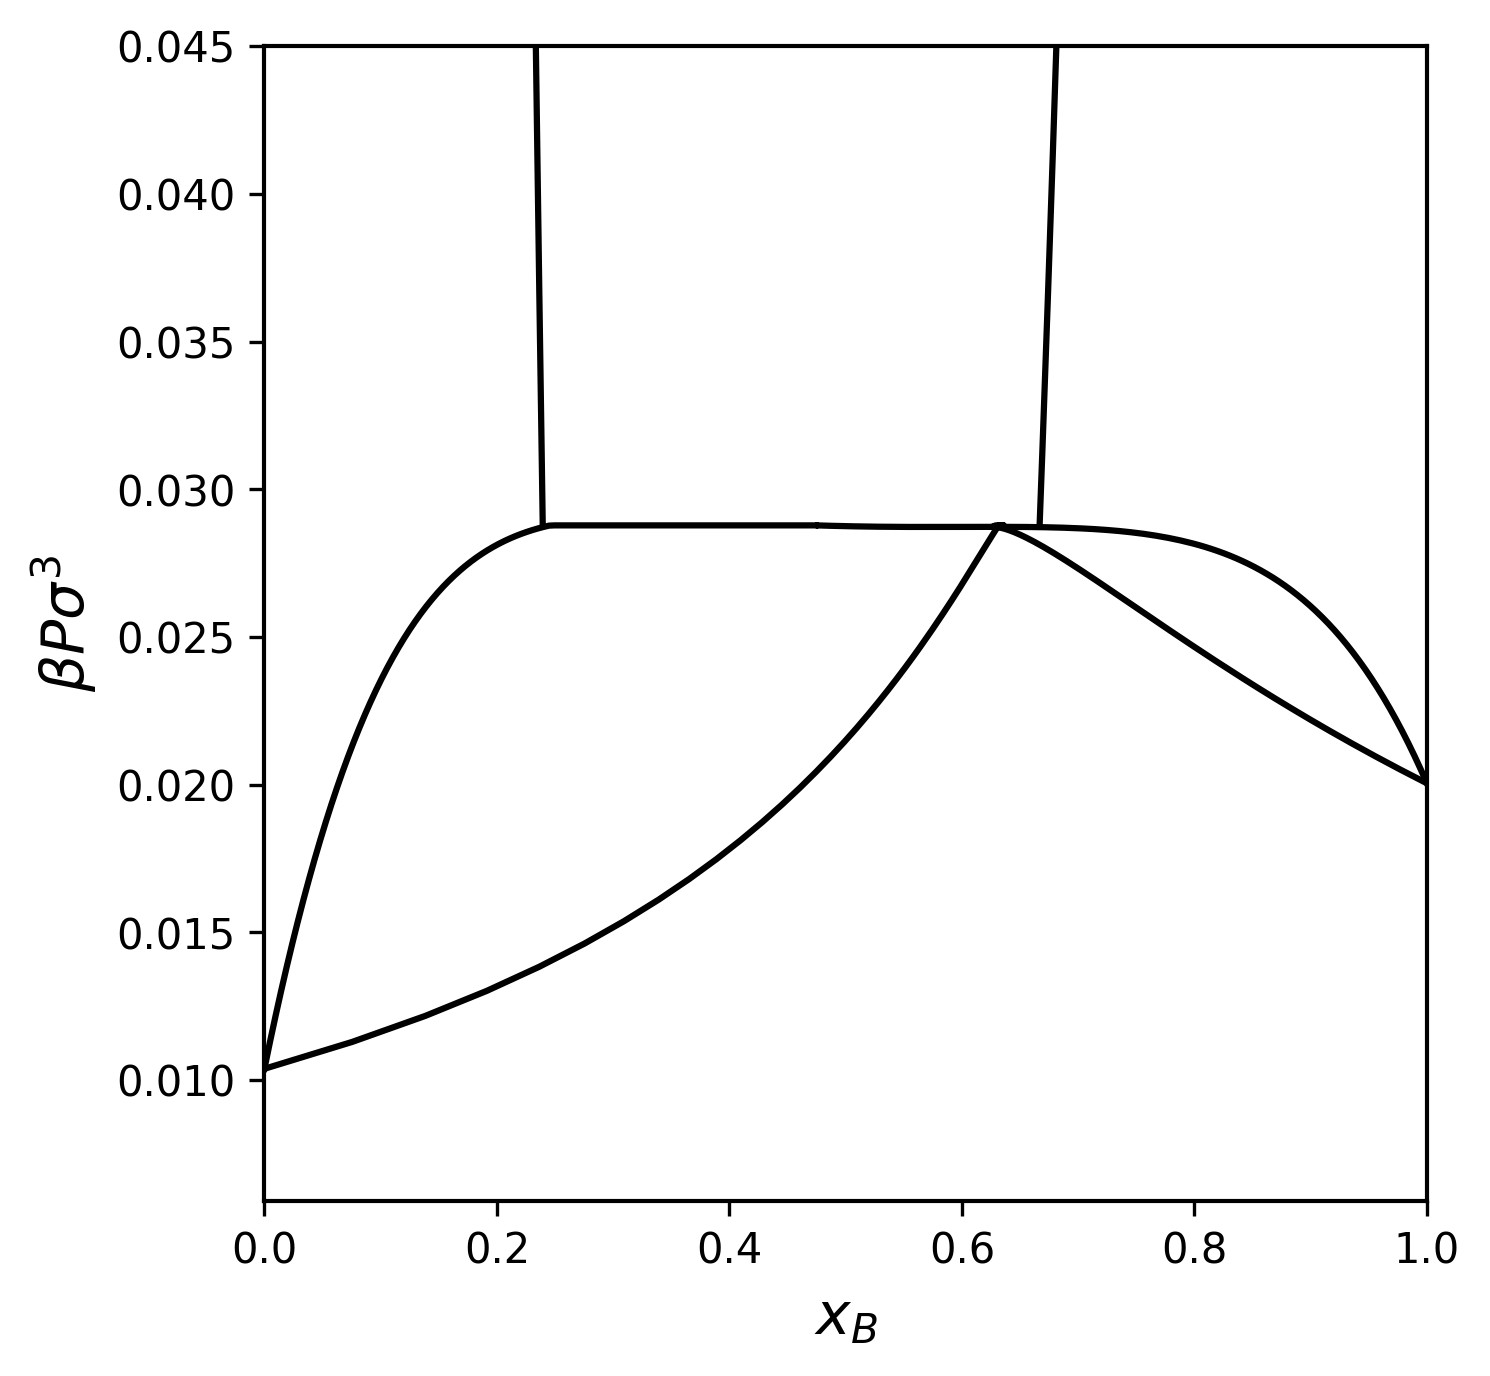

In [4]:
parameters = PetsParameters.from_lists(sigma = sigma,
                                       epsilon_k = np.array([eps_AA, eps_BB]),
                                       k_ij = np.array([[0, int_param], [int_param, 0]])
                                       )

pets_hetero = EquationOfState.pets(parameters)

dia_hetero = PhaseDiagram.binary_vlle(eos=pets_hetero,
                                    temperature_or_pressure=T*si.KELVIN,
                                    x_lle=(0.66, 0.36),
                                    npoints_lle=200, npoints_vle=200,
                                    tp_lim_lle=0.1 * (si.KELVIN * si.KB / si.ANGSTROM**3))

vle_pressure = dia_hetero.vle.vapor.pressure / (si.KELVIN * si.KB / si.ANGSTROM**3)
lle_pressure = dia_hetero.lle.vapor.pressure / (si.KELVIN * si.KB / si.ANGSTROM**3)

vle_pressure[vle_pressure > np.min(lle_pressure)] = np.min(lle_pressure)

fig, axs = plt.subplots(figsize=(5,5))

axs.plot(dia_hetero.vle.liquid.molefracs[:, 1], vle_pressure, color='black')
axs.plot(dia_hetero.vle.vapor.molefracs[:, 1],  vle_pressure, color='black')
axs.plot(dia_hetero.lle.liquid.molefracs[:, 1], lle_pressure, color='black')
axs.plot(dia_hetero.lle.vapor.molefracs[:, 1],  lle_pressure, color='black')

axs.set_xlim(0, 1)
axs.set_ylim(top=0.045)

axs.set_ylabel("$P \\sigma^3 $ / $ϵ$")
axs.set_xlabel("$x_\\text{B}$")

plt.show()

# For the heteroazeotrope point
hetero_point = PhaseEquilibrium.heteroazeotrope(eos=pets_hetero,
                                              temperature_or_pressure=T*si.KELVIN,
                                              x_init=(0.36, 0.66))
#print(hetero_point)


#### Pick a state point

In [5]:
x = 0.60 # x_B
p = 0.020

s = State(
    eos=pets_hetero,
    temperature=T*si.KELVIN,
    molefracs = np.array([1-x, x]),
    pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
    )

rho_tot = s.density * si.NAV * si.ANGSTROM**3
rho_mixture = rho_tot*np.array([1-x, x])
betamu = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture)

#### Minimise

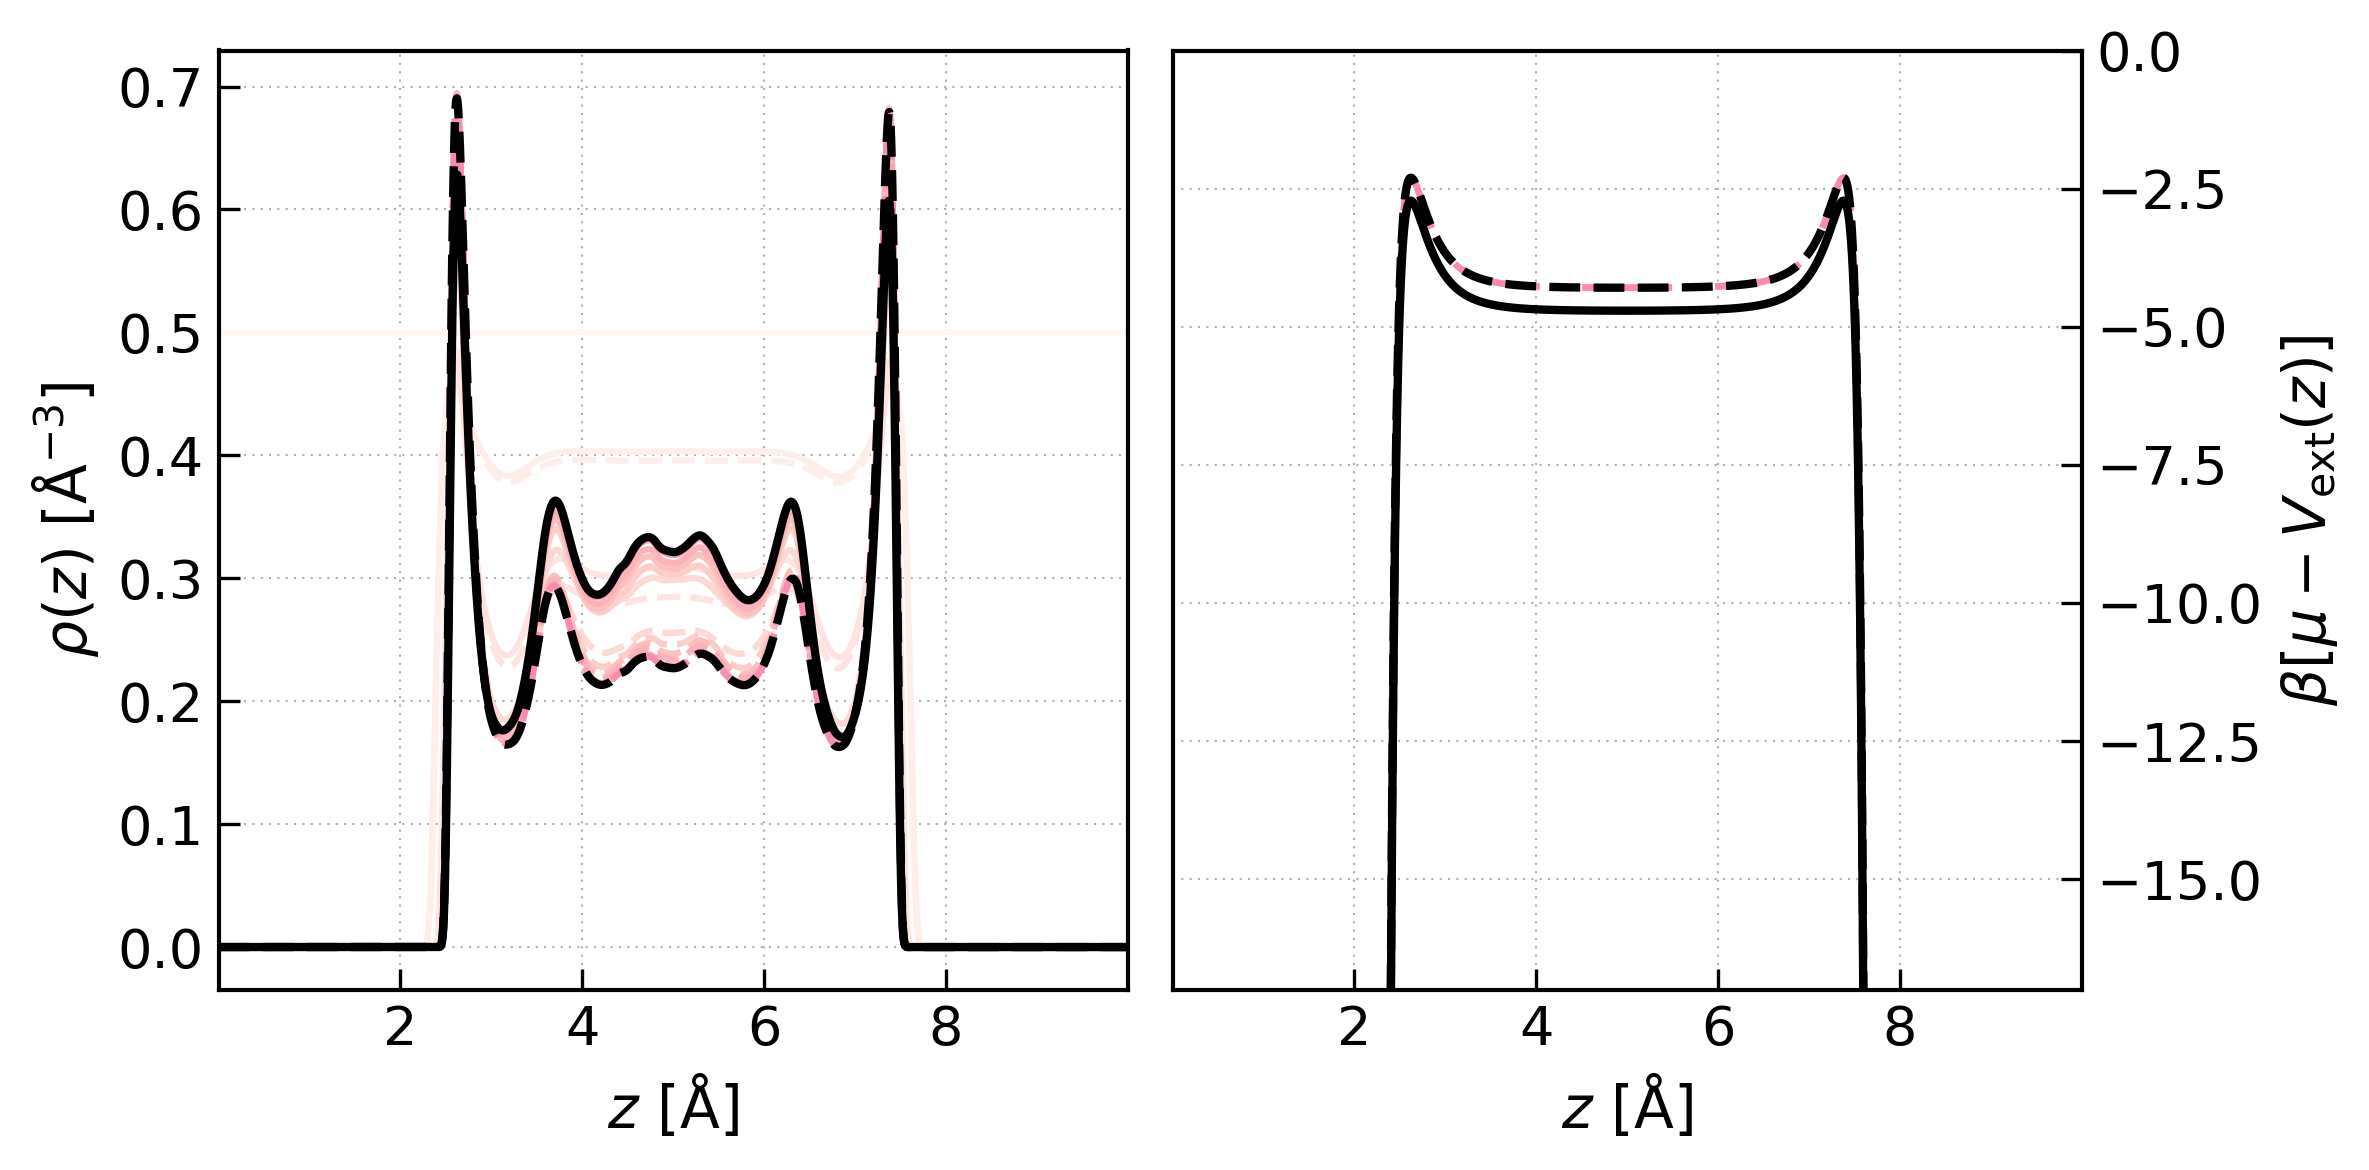

In [9]:
output_file = "../density_profile.dat"
L = 8 # Slit length
width = 1.5 # Slit wall width
eps_w = 2.0

get_slit_profile_lr(model_path, output_file, T,
                    mu_A = betamu[0], mu_B = betamu[1],
                    rho_b_A = rho_mixture[0], rho_b_B = rho_mixture[1],
                    eps_AA = eps_AA, eps_BB = eps_BB, int_param = int_param,
                    L = (L+2*width), low_wall = width, high_wall = L + width, eps_wall = eps_w
                    )

## Constant Pressure Minimisations Through Coexistence Region

In [8]:
p = 0.040
mol_frac = np.linspace(0.02, 0.98, num=25)

Text(0.5, 0, '$x_B$')

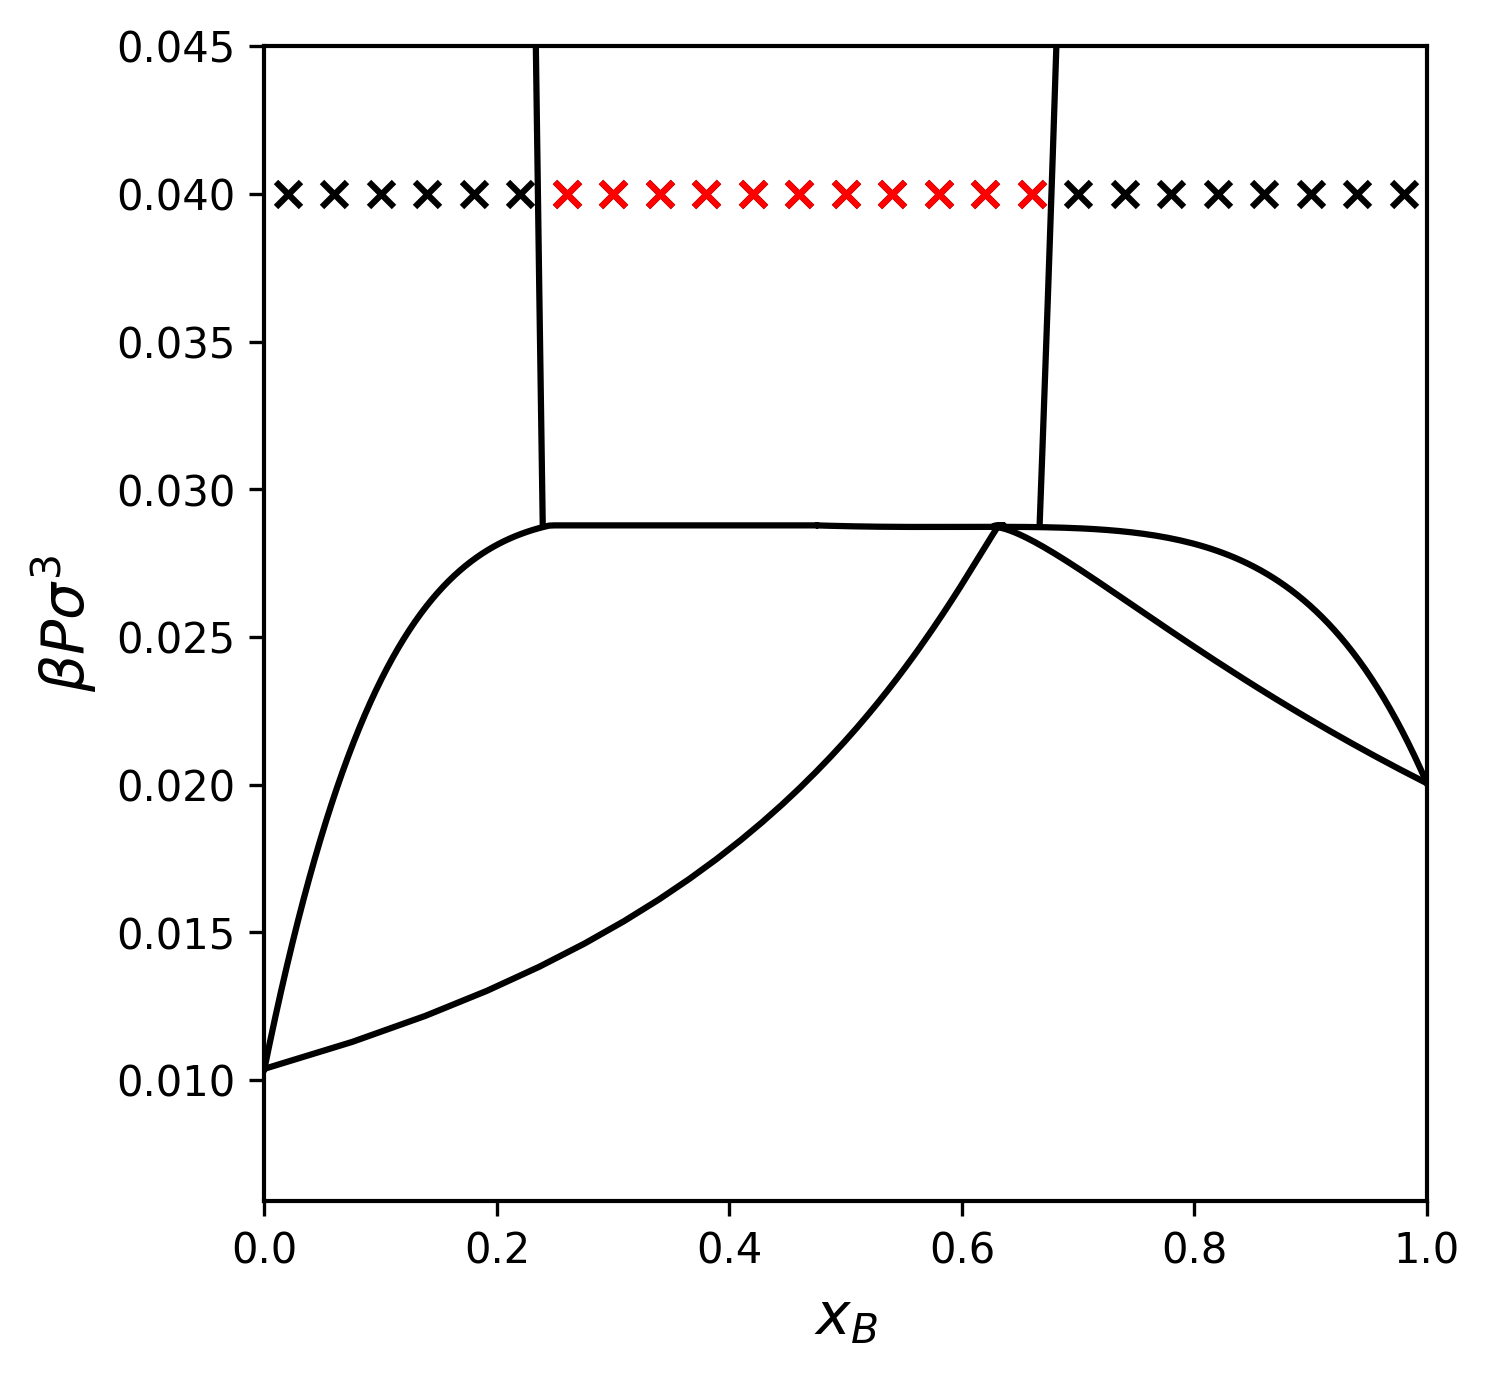

In [9]:
def find_nearest(array, target, num):
    array = np.asarray(array)
    distances = np.abs(array - target)
    nearest_indices = np.argsort(distances)[:num]
    nearest_values = array[nearest_indices]
    return nearest_indices

if p < np.min(lle_pressure): # System is VLE
    nearest_idx = find_nearest(vle_pressure, p, 4)
    # Initialize list of coexistence regions as (x_min, x_max) tuples
    coexistence_regions = []

    x1_min = min(dia_hetero.vle.liquid.molefracs[nearest_idx[0], 1], dia_hetero.vle.vapor.molefracs[nearest_idx[0], 1])
    x1_max = max(dia_hetero.vle.liquid.molefracs[nearest_idx[0], 1], dia_hetero.vle.vapor.molefracs[nearest_idx[0], 1])
    coexistence_regions.append((x1_min, x1_max))

    # Second region (if indices are not adjacent)
    if np.abs(nearest_idx[1] - nearest_idx[0]) != 1:
        x2_min = min(dia_hetero.vle.liquid.molefracs[nearest_idx[1], 1], dia_hetero.vle.vapor.molefracs[nearest_idx[1], 1])
        x2_max = max(dia_hetero.vle.liquid.molefracs[nearest_idx[1], 1], dia_hetero.vle.vapor.molefracs[nearest_idx[1], 1])
        coexistence_regions.append((x2_min, x2_max))

    mask = np.full_like(mol_frac, False, dtype=bool)
    for x_min, x_max in coexistence_regions:
        mask |= (mol_frac >= x_min) & (mol_frac <= x_max)

    coexistence_x = mol_frac[mask]

else: # System is LLE
    nearest_idx = find_nearest(lle_pressure, p, 4)
    # Initialize list of coexistence regions as (x_min, x_max) tuples
    coexistence_regions = []

    x1_min = min(dia_hetero.lle.liquid.molefracs[nearest_idx[0], 1], dia_hetero.lle.vapor.molefracs[nearest_idx[0], 1])
    x1_max = max(dia_hetero.lle.liquid.molefracs[nearest_idx[0], 1], dia_hetero.lle.vapor.molefracs[nearest_idx[0], 1])
    coexistence_regions.append((x1_min, x1_max))

    # Second region (if indices are not adjacent)
    if np.abs(nearest_idx[1] - nearest_idx[0]) != 1:
        x2_min = min(dia_hetero.lle.liquid.molefracs[nearest_idx[1], 1], dia_hetero.lle.vapor.molefracs[nearest_idx[1], 1])
        x2_max = max(dia_hetero.lle.liquid.molefracs[nearest_idx[1], 1], dia_hetero.lle.vapor.molefracs[nearest_idx[1], 1])
        coexistence_regions.append((x2_min, x2_max))

    mask = np.full_like(mol_frac, False, dtype=bool)
    for x_min, x_max in coexistence_regions:
        mask |= (mol_frac >= x_min) & (mol_frac <= x_max)

    coexistence_x = mol_frac[mask]

fig, axs = plt.subplots(figsize=(5,5))

axs.scatter(mol_frac, [p]*len(mol_frac), color="black", marker="x")
axs.scatter(coexistence_x, [p]*len(coexistence_x), color="red", marker="x")

axs.plot(dia_hetero.vle.liquid.molefracs[:, 1], vle_pressure, color='black')
axs.plot(dia_hetero.vle.vapor.molefracs[:, 1],  vle_pressure, color='black')
axs.plot(dia_hetero.lle.liquid.molefracs[:, 1], lle_pressure, color='black')
axs.plot(dia_hetero.lle.vapor.molefracs[:, 1],  lle_pressure, color='black')

axs.set_xlim(0, 1)
axs.set_ylim(top=0.045)
axs.set_ylabel("$P \\sigma^3 $ / $ϵ$")
axs.set_xlabel("$x_\\text{B}$")


#### Obtain coexistence chemical potentials

In [10]:
coexistence_densities = []
coex_mu = []
tot_density = []

for x_min, x_max in coexistence_regions:
    # Determine coex mu by averaging over chemical potentials at boundaries
    # Coexistence densities are values at these boundaries

        s = State(
            eos=pets_hetero,
            temperature=T*si.KELVIN,
            molefracs = np.array([1-x_min, x_min]),
            pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
            )

        rho = s.density * si.NAV * si.ANGSTROM**3
        rho_mixture1 = rho*np.array([1-x_min, x_min])

        betamu1 = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture1)

        s = State(
            eos=pets_hetero,
            temperature=T*si.KELVIN,
            molefracs = np.array([1-x_max, x_max]),
            pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
            )

        rho = s.density * si.NAV * si.ANGSTROM**3
        rho_mixture2 = rho*np.array([1-x_max, x_max])

        betamu2 = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture2)

        coex_mu.append( list(np.mean( np.array([ betamu1, betamu2 ]), axis=0 ) ))
        coexistence_densities.append([rho_mixture1, rho_mixture2])
        tot_density.append([np.sum(rho_mixture1), np.sum(rho_mixture2)])


#### Pick a state point and minimise

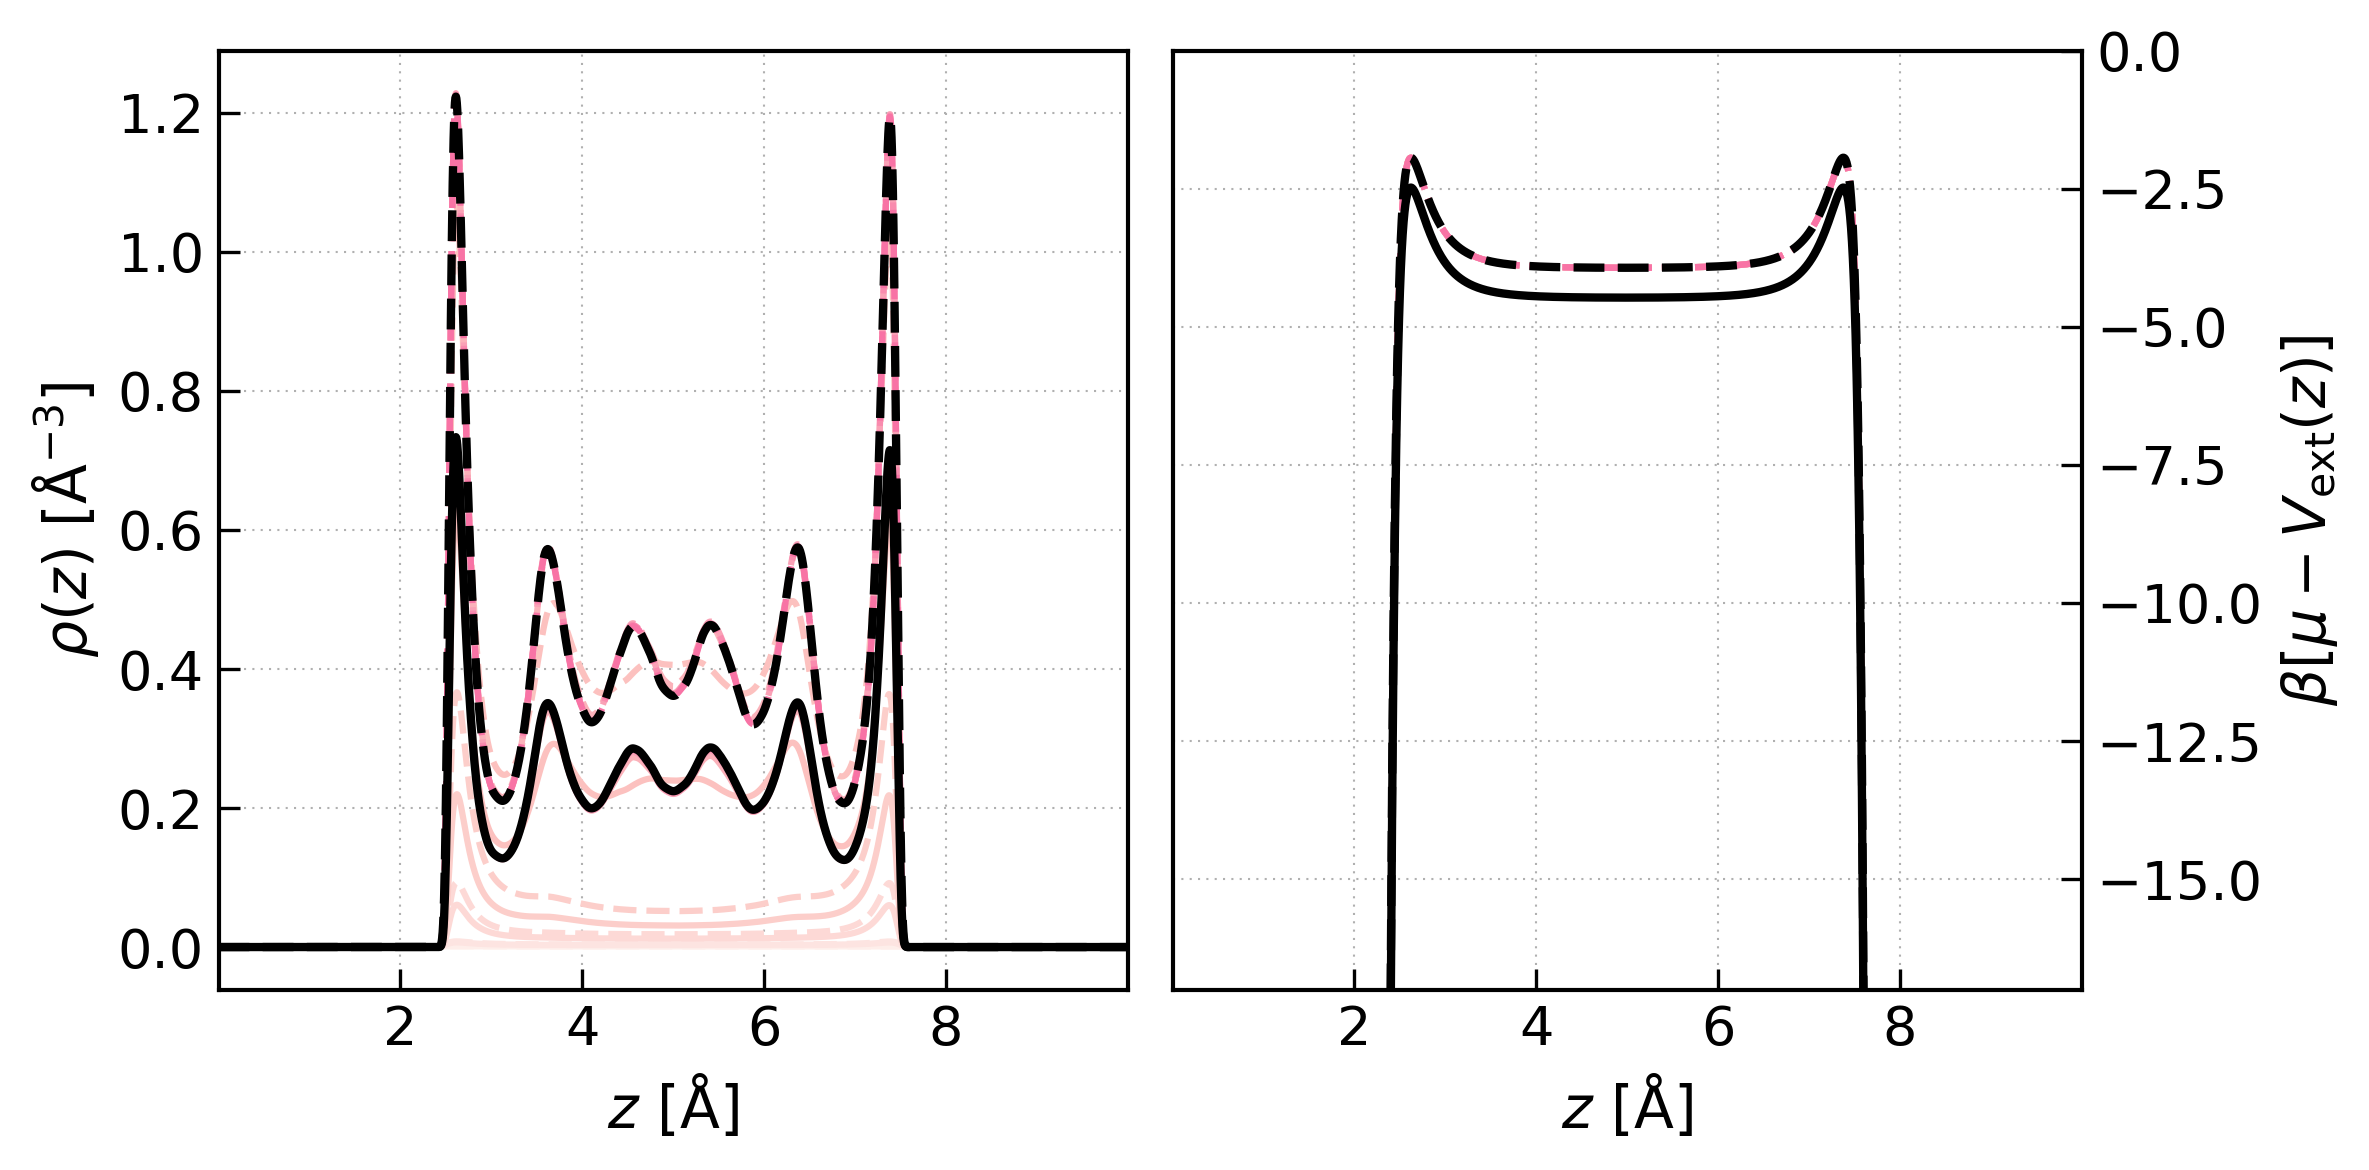

In [12]:
x = 0.35 # x_B
initial_guess = 0.001

rho_mixture = None

# Determine if x is in the coexistence region
for i, (x_min, x_max) in enumerate(coexistence_regions): 
    if x_min <= x <= x_max:
        betamu = coex_mu[i]
        if initial_guess == 1:
            idx = np.argmax(tot_density[i])
        elif initial_guess == 0.001:
            idx = np.argmin(tot_density[i])
        rho_mixture = coexistence_densities[i][idx]

if rho_mixture is None:
    s = State(
        eos=pets_hetero,
        temperature=T*si.KELVIN,
        molefracs = np.array([1-x, x]),
        pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
        )

    rho_tot = s.density * si.NAV * si.ANGSTROM**3
    rho_mixture = rho_tot*np.array([1-x, x])
    betamu = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture)


output_file = "../density_profile.dat"
L = 8 # Slit length
width = 1.5 # Slit wall width
eps_w = 2.0

get_slit_profile_lr(model_path, output_file, T,
                    mu_A = betamu[0], mu_B = betamu[1],
                    rho_b_A = rho_mixture[0], rho_b_B = rho_mixture[1],
                    eps_AA = eps_AA, eps_BB = eps_BB, int_param = int_param,
                    L = (L+2*width), low_wall = width, high_wall = L + width, eps_wall = eps_w,
                    initial_guess_A = initial_guess, initial_guess_B = initial_guess
                    )